In [16]:
import pandas as pd
import geopandas as gpd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import unicodedata
import libpysal
import networkx as nx
import plotly.express as px
import re
from matplotlib import cm
from sklearn.manifold import MDS
from sklearn.metrics import pairwise_distances
from pathlib import Path

### Data Preparation

In [17]:
# Dataset preparation
# - remove thousand dots
# - replace decimal commas with dots
# - convert numeric-like strings to numbers; leave strings with letters/% as text
# - normalize province names in-place (overwrite 'prov')
# - hardcoded some provinces names for future merging 
# - save cleaned CSV


INPUT_FILE = "../data/ECEC_labour_2022 dataset.xlsx"  
SHEET = "Sheet1"
OUTDIR = Path("../data")

# Matches dots that are thousand separators: a dot between digits and followed by exactly 3 digits
_THOUSAND_DOT = re.compile(r"(?<=\d)\.(?=\d{3}(\D|$))")

def clean_number_string(x):
    
    if pd.isna(x):
        return x
    s = str(x).strip()
    if s == "":
        return s
    if re.search(r"[A-Za-z%]", s):
        return s.replace("\u00A0", "").strip()
    s = _THOUSAND_DOT.sub("", s)
    s = s.replace("\u00A0", "").replace(" ", "")
    s = s.replace(",", ".")
    return s

def convert_object_numeric(df: pd.DataFrame, threshold: float = 0.7) -> pd.DataFrame:
    
    df = df.copy()
    num_pattern = re.compile(r"^-?\d+(\.\d+)?$")
    for c in df.columns:
        if df[c].dtype == "object":
            cleaned = df[c].map(clean_number_string)
            non_na = cleaned[~pd.isna(cleaned)]
            is_numlike = non_na.map(lambda v: bool(num_pattern.fullmatch(str(v))))
            ratio = (is_numlike.mean() if len(non_na) else 0.0)
            if ratio >= threshold:
                df[c] = pd.to_numeric(cleaned, errors="coerce")
            else:
                df[c] = cleaned
    return df

def norm(s):
    s = str(s).strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
    s = s.replace('-', ' ').replace('/', ' ').replace("'", '').replace('’','')
    s = ' '.join(s.split()).lower()
    return s


df = pd.read_excel(INPUT_FILE, sheet_name=SHEET)
df_clean = convert_object_numeric(df)

if 'prov' in df_clean.columns:
    df_clean['prov'] = df_clean['prov'].apply(norm)
    map = {
        'valle daosta vallee daoste': 'aosta',
        'reggio calabria': 'reggio di calabria',
        'bolzano bozen': 'bolzano',
    }
    df_clean['prov'] = df_clean['prov'].replace(map)

csv_path = OUTDIR / "cleaned_ECEC_labour_2022 dataset.csv"
df_clean.to_csv(csv_path, index=False, encoding="utf-8")

In [18]:
# Merging csv and geojson into a single file (still geojson to preserve geometry of provinces)

def norm(s):
    s = str(s).strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
    s = s.replace('-', ' ').replace('/', ' ').replace("'", '').replace('’','')
    s = ' '.join(s.split()).lower()
    return s

csv_path = r"..\data\cleaned_ECEC_labour_2022 dataset.csv"
df = pd.read_csv(csv_path)
df['join_key'] = df['prov'].apply(norm)


gjson_path = r"..\data\georef-italy-provincia.geojson"
gdf = gpd.read_file(gjson_path)

gdf['join_key'] = gdf['prov_name'].apply(norm)

manual_map = {
    'verbano cusio ossola': 'verbano cusio ossola',
    'valle daosta vallee daoste': 'valle daosta vallee daoste',
}
gdf['join_key'] = gdf['join_key'].replace(manual_map)

merged = gdf.merge(df, on='join_key', how='left')

unmatched = merged[merged['population'].isna()][['prov_name']]
print('Unmatched provinces:', unmatched.shape[0])
if unmatched.shape[0] > 0 :
    print(unmatched.head())

out_path = r"..\data\merged_ecec_province.geojson"
merged.to_file(out_path, driver='GeoJSON')

Unmatched provinces: 0


### Data Exploration and Visualization

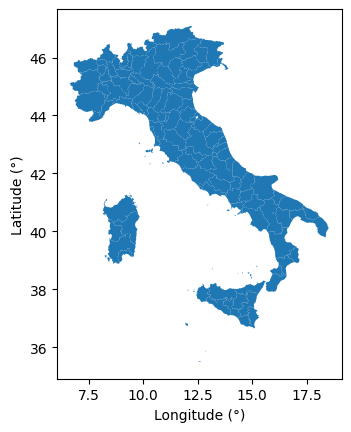

In [19]:
# Basic visualization of the italian provinces

gdf = gpd.read_file("../data/merged_ecec_province.geojson")

gdf.plot()
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.show()

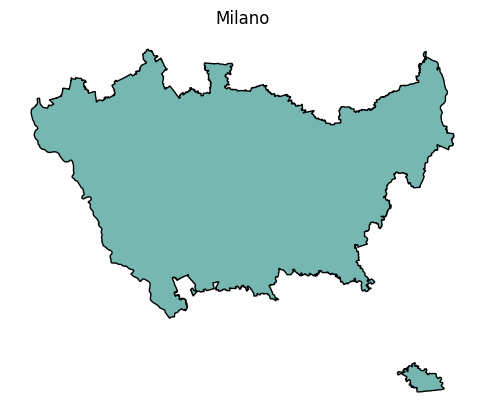

In [20]:
# Plotting one single province

name_col = "prov_name"
province = gdf[gdf["prov_name"] == "Milano"]

ax = province.plot(edgecolor="black", facecolor="#76b7b2", figsize=(6, 6))
plt.axis("off")
plt.title(province.iloc[0][name_col] if not province.empty else "Province not found")
plt.show()


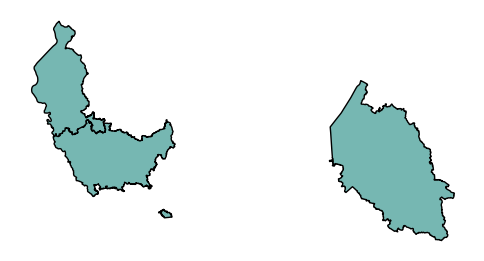

In [21]:
# Plotting multiple province

name_col = "prov_name"
province = gdf[gdf["prov_name"] == "Milano"]

ax = province.plot(edgecolor="black", facecolor="#76b7b2", figsize=(6, 6))
plt.axis("off")

province = gdf[gdf["prov_name"] == "Varese"]
province.plot(ax=ax, edgecolor="black", facecolor="#76b7b2", figsize=(6, 6))

province = gdf[gdf["prov_name"] == "Verona"]
province.plot(ax=ax, edgecolor="black", facecolor="#76b7b2", figsize=(6, 6))

plt.show()

c:\Users\leona\Desktop\POLIMI\Programmi\.venv\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)
C:\Users\leona\AppData\Local\Temp\ipykernel_29960\2634162325.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_colors)


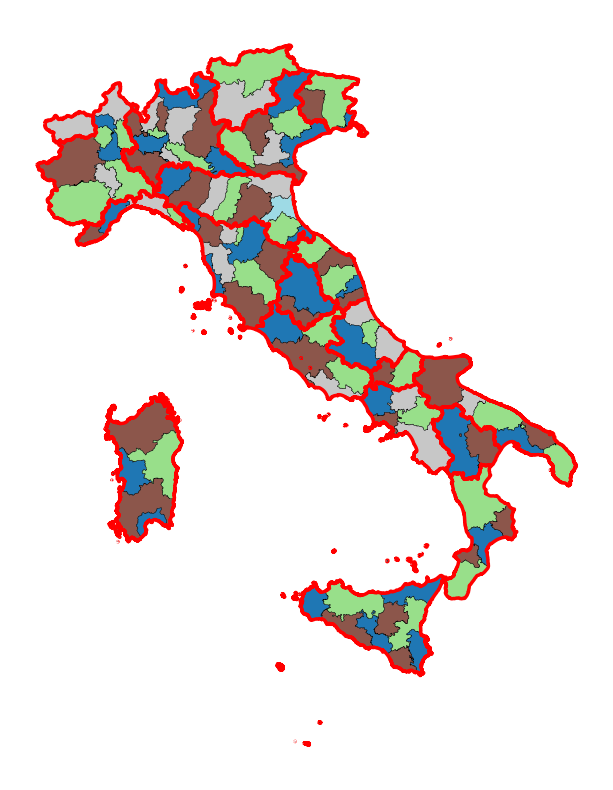

In [22]:
# Plot provinces with different colours for adjacent ones
# Plot thicker bounds for REGIONS

gdf = gpd.read_file(r"..\data\merged_ecec_province.geojson")

w = libpysal.weights.Queen.from_dataframe(gdf, ids=gdf.index)
G = nx.Graph()
for i, neighbors in w.neighbors.items():
    for j in neighbors:
        if i < j:
            G.add_edge(i, j)

colors = nx.coloring.greedy_color(G, strategy="largest_first") 
gdf["color_id"] = gdf.index.map(colors)

n_colors = gdf["color_id"].max() + 1
cmap = cm.get_cmap("tab20", n_colors) 

ax = gdf.plot(
    column="color_id",
    cmap=cmap,
    edgecolor="black",
    linewidth=0.3,
    figsize=(8, 10),
)

regions = gdf.dissolve(by="reg_name")
regions.boundary.plot(ax=ax, color="red", linewidth=2.5)

plt.axis("off")
plt.show()

c:\Users\leona\Desktop\POLIMI\Programmi\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


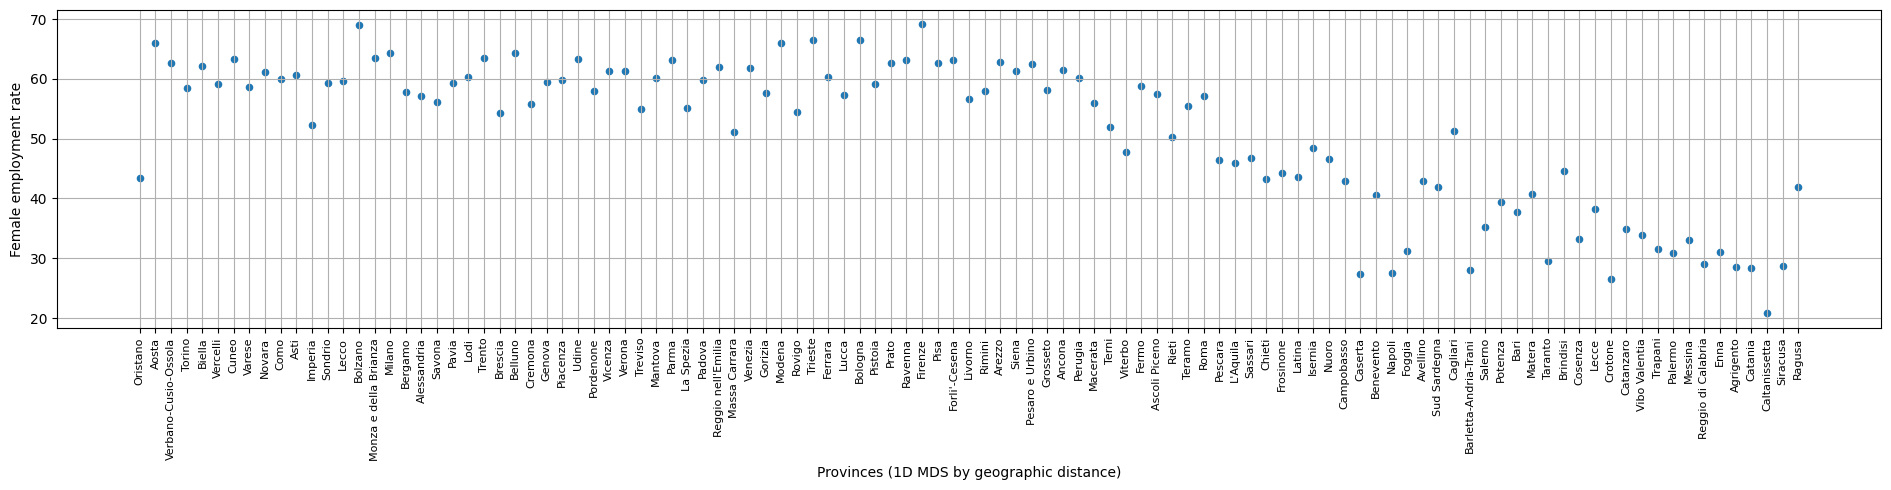

In [23]:
# Embed provinces on 1D
# Plot female employment rate

gdf = gpd.read_file(r"..\data\merged_ecec_province.geojson")

# Project to a metric CRS for Euclidean distances
centroids = gdf.to_crs(3857).geometry.centroid
coords = np.column_stack([centroids.x, centroids.y])

# 1D embedding via MDS on pairwise geographic distances
D = pairwise_distances(coords, metric="euclidean")
x1d = MDS(n_components=1, dissimilarity="precomputed", random_state=0).fit_transform(D).ravel()

# Order provinces by their 1D coordinate
order = np.argsort(x1d)
prov_names = gdf["prov_name"].to_numpy()[order]
y = pd.to_numeric(gdf["fem_empl_rate"]).to_numpy()[order]

x = np.arange(len(prov_names))
fig_width = max(12, 0.22 * len(prov_names))
fig, ax = plt.subplots(figsize=(fig_width, 6))

ax.scatter(x, y, s=20)
ax.set_ylabel("Female employment rate")
ax.set_xlabel("Provinces (1D MDS by geographic distance)")
ax.set_xticks(x)
ax.set_xticklabels(prov_names, rotation=90, ha="center")
ax.tick_params(axis="x", labelsize=8)
fig.subplots_adjust(bottom=0.35)
plt.grid(True)
plt.show()


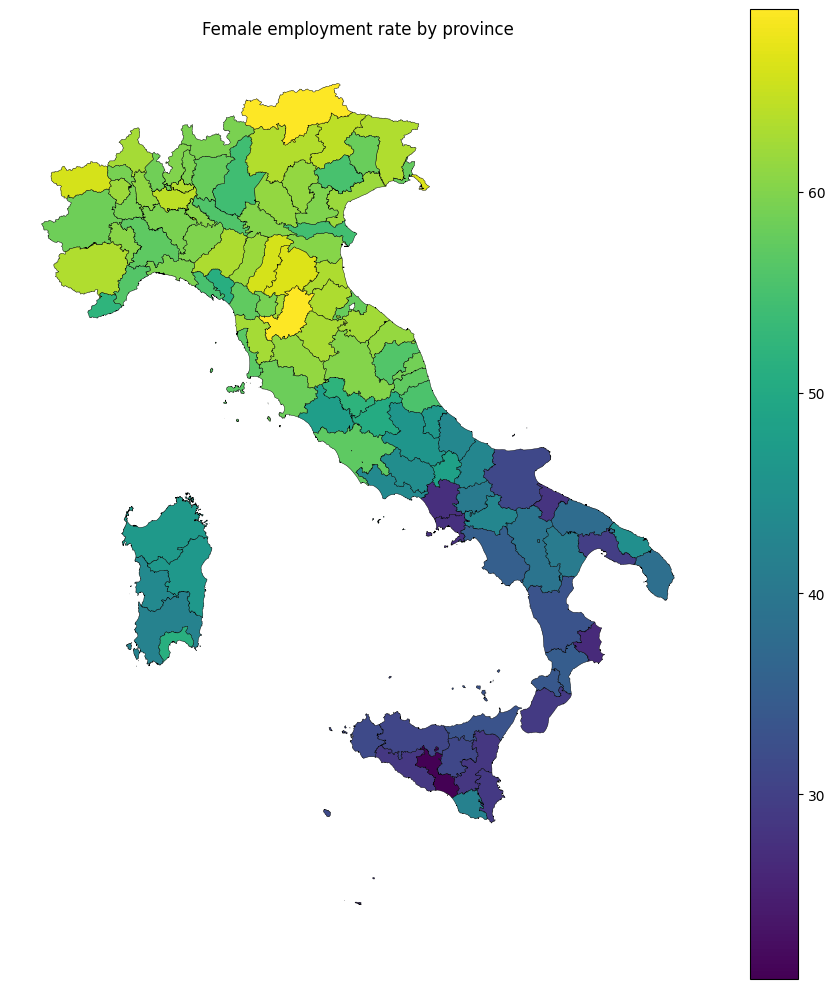

In [24]:
# Plot provinces and colour them based on female employment rate

gdf = gpd.read_file(r"..\data\merged_ecec_province.geojson")

gdf["fem_empl_rate_num"] = pd.to_numeric(gdf["fem_empl_rate"])

ax = gdf.plot(
    column="fem_empl_rate_num",
    cmap="viridis",
    edgecolor="black",
    linewidth=0.3,
    figsize=(9, 10),
    legend=True,
    missing_kwds={"color": "lightgrey", "edgecolor": "white", "hatch": "///", "label": "No data"}
)

plt.title("Female employment rate by province")
plt.axis("off")
plt.tight_layout()
plt.show()


### Studying Correlation

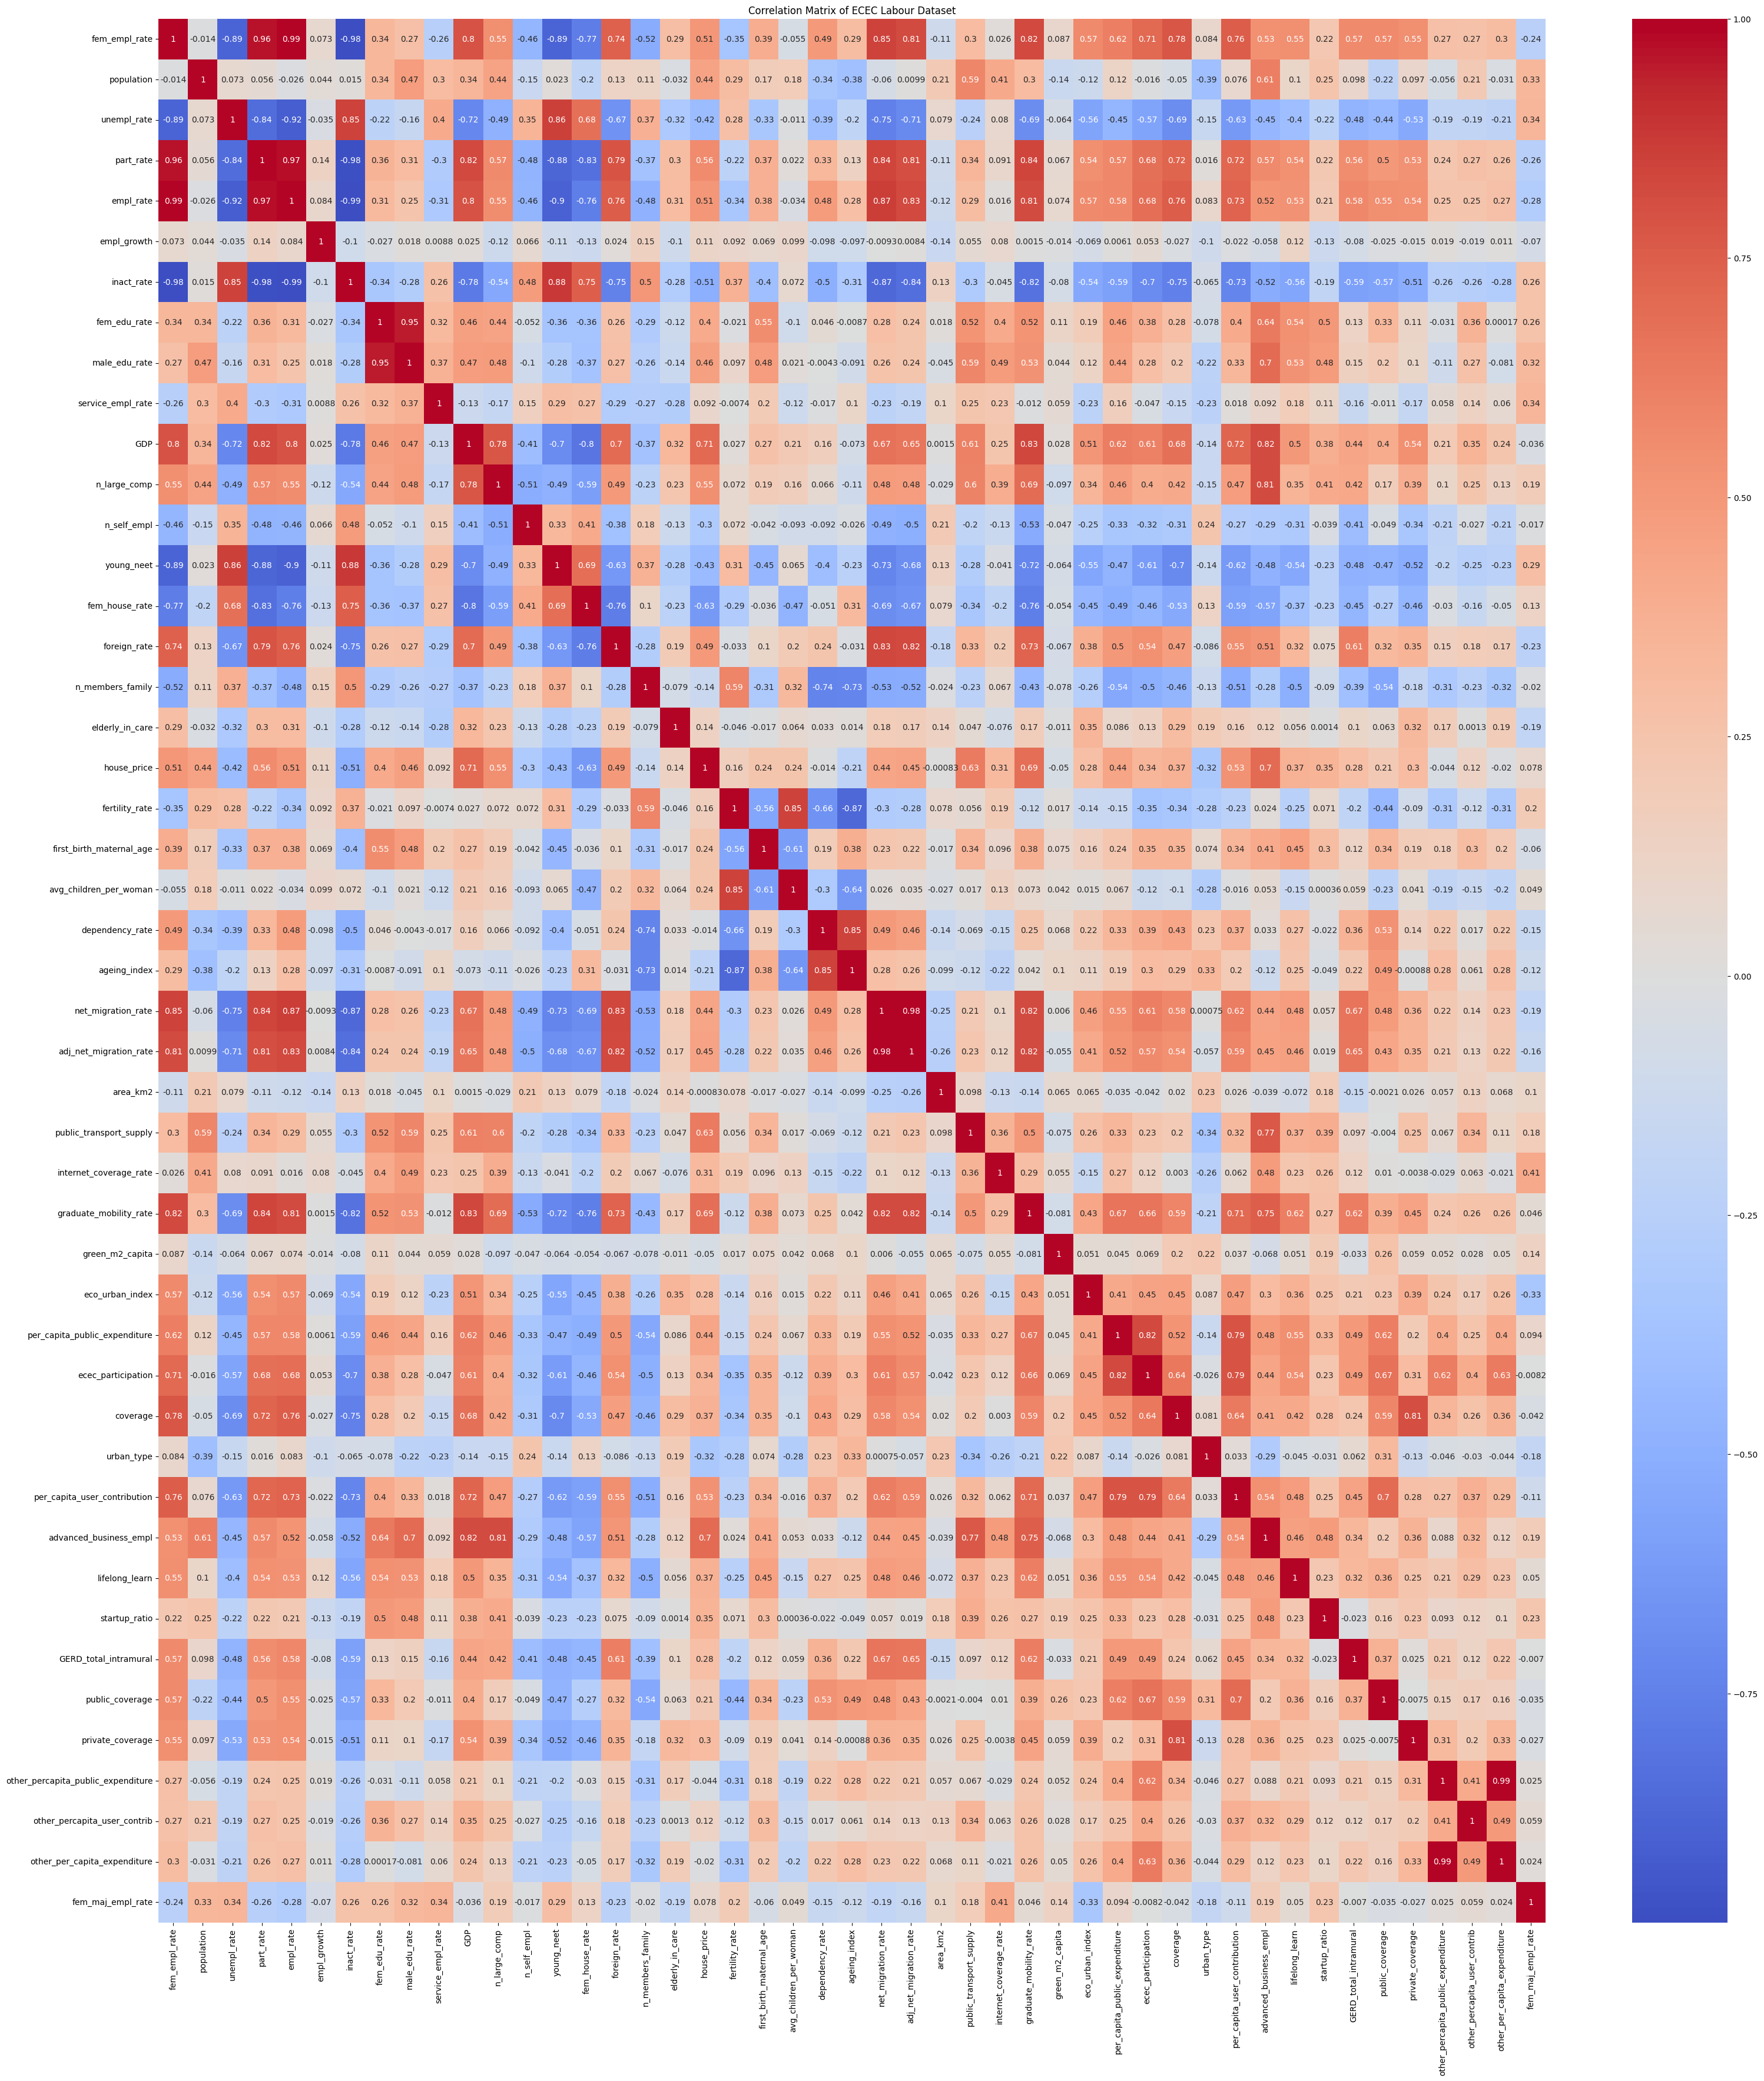

In [ ]:
# Plotting correletaion matrix

df = pd.read_csv("../data/cleaned_ECEC_labour_2022 dataset.csv")

corr = df.drop(columns=['prov']).corr(method='pearson')

plt.figure(figsize=(38,42))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True)
plt.title("Correlation Matrix of ECEC Labour Dataset")
plt.show()
